In [1]:
import nibabel as nib
import numpy as np
import hippomaps as hm
import pandas as pd
from glob import glob

/export03/data/opt/venv/lib/python3.8/site-packages/nilearn/datasets/__init__.py:93: FutureWarning: Fetchers from the nilearn.datasets module will be updated in version 0.9 to return python strings instead of bytes and Pandas dataframes instead of Numpy arrays.
  warn("Fetchers from the nilearn.datasets module will be "


In [2]:
# locate input data
pet_dir = '/data/mica3/MICA-PET/derivatives_REP/micapet'
dwi_dir = '/data/mica3/BIDS_MICs/derivatives/micapipe_v0.2.0/'
hippunfold_dir = '/data/mica3/BIDS_MICs/derivatives/hippunfold_v1.3.0/hippunfold'

# define which subjects and surfaces to examine
hemis = ['L','R']
labels = ['hipp']#,'dentate']
den = '0p5mm'
ses='ses-01'

# get expected number of vertices and their indices
nV,iV = hm.config.get_nVertices(labels,den)

features = ['Tau','FA', 'ADC', 'thickness']

In [3]:
df = pd.read_excel('Jordan-SPINDLE_HC.xlsx',sheet_name='orginal hc-px MATCHING')
df

,#,PX-EMU,sex,age,PX-HC matched,HC age,id,age at time of MRI scan,sex.1
0,1.0,PX012,33.0,F,HC030,34.460274,HC002,25.273973,M
1,2.0,PX017,28.0,F,HC012,27.087671,HC003,22.161644,F
2,3.0,PX020,52.0,M,HC053,57.805479,HC004,36.621918,M
3,4.0,PX025,25.0,M,HC013,24.904110,HC005,23.613699,M
4,5.0,PX034,51.0,M,HC029,44.580822,HC006,22.813699,M
...,...,...,...,...,...,...,...,...,...
121,NaN,NaN,NaN,NaN,NaN,NaN,HC123,36,F
122,NaN,NaN,NaN,NaN,NaN,NaN,HC124,33,F
123,NaN,NaN,NaN,NaN,NaN,NaN,HC125,?,F
124,NaN,NaN,NaN,NaN,NaN,NaN,HC126,?,F


In [4]:
hippTau_HC = np.ones((nV,2,len(df['PX-HC matched']),len(features)))*np.nan
!mkdir -p tmp
for s,sub in enumerate(df['PX-HC matched']):
    for h,hemi in enumerate(hemis):
        for f,feature in enumerate(features):
            surf = f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_midthickness.surf.gii'
            if feature == 'Tau':
                volname = f'{pet_dir}/sub-{sub}/{ses}/pet/sub-{sub}_{ses}_pet-mkAVG-t1w_normalized.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii -trilinear'
                !{cmd}
                try:
                    hippTau_HC[:,h,s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii').darrays[0].data
                except:
                    print(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii')
            elif feature=='thickness':
                try:
                    hippTau_HC[:,h,s,f] = nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii').darrays[0].data * nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_surfarea.shape.gii').darrays[0].data
                except:
                    print(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii')
            else:
                volname = f'{dwi_dir}/sub-{sub}/{ses}/maps/sub-{sub}_{ses}_space-nativepro_model-DTI_map-{feature}.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii -trilinear'
                !{cmd}
                try:
                    hippTau_HC[:,h,s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii').darrays[0].data
                except:
                    print(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii')
!rm -rf tmp*

In [5]:
rm = np.all(np.isnan(hippTau_HC),axis=(0,1,3))
hippTau_HC = np.delete(hippTau_HC,rm,axis=2)

In [6]:
data = {'sub':df['PX-HC matched'][df['PX-HC matched'].notnull()], 
        'AvgTau_L': np.mean(hippTau_HC[:,0,:,0],axis=0), 'AvgTau_R': np.mean(hippTau_HC[:,1,:,0],axis=0),
        'AvgFA_L': np.mean(hippTau_HC[:,0,:,1],axis=0), 'AvgFA_R': np.mean(hippTau_HC[:,1,:,1],axis=0),
        'AvgADC_L': np.mean(hippTau_HC[:,0,:,2],axis=0), 'AvgADC_R': np.mean(hippTau_HC[:,1,:,2],axis=0),
        'AvgCV_L': np.mean(hippTau_HC[:,0,:,3],axis=0), 'AvgCV_R': np.mean(hippTau_HC[:,1,:,3],axis=0),
        }            
df2 = pd.DataFrame(data=data)
df2.to_csv('avgHippTau_HC.csv')

/export03/data/opt/BrainSpace/brainspace/plotting/base.py:287: UserWarning: Interactive mode requires 'panel'. Setting 'interactive=False'
  warnings.warn("Interactive mode requires 'panel'. "


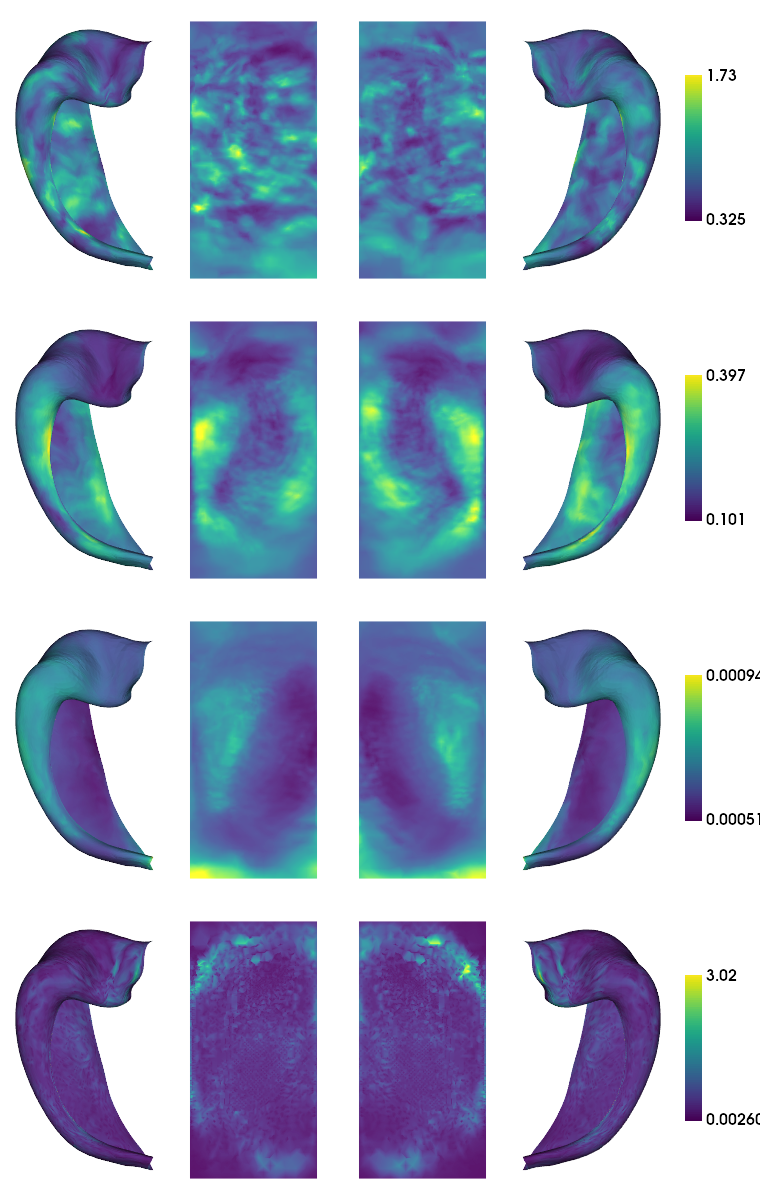

In [7]:
hm.plotting.surfplot_canonical_foldunfold(np.nanmean(hippTau_HC,axis=2),labels=labels, hemis=hemis, tighten_cwindow=False, color_bar='right', share='row', den=den, embed_nb=True)

In [8]:
# difference
hippTau_PX = np.ones((nV,2,len(df['PX-EMU']),len(features)))*np.nan
!mkdir -p tmp
for s,sub in enumerate(df['PX-EMU']):
    for h,hemi in enumerate(hemis):
        for f,feature in enumerate(features):
            surf = f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_midthickness.surf.gii'
            if feature == 'Tau':
                volname = f'{pet_dir}/sub-{sub}/{ses}/pet/sub-{sub}_{ses}_pet-mkAVG-t1w_normalized.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii -trilinear'
                !{cmd}
                try:
                    hippTau_PX[:,h,s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii').darrays[0].data
                except:
                    print(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii')
            elif feature=='thickness':
                try:
                    hippTau_PX[:,h,s,f] = nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii').darrays[0].data * nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_surfarea.shape.gii').darrays[0].data
                except:
                    print(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{hemi}_space-T1w_den-0p5mm_label-hipp_thickness.shape.gii')
            else:
                volname = f'{dwi_dir}/sub-{sub}/{ses}/maps/sub-{sub}_{ses}_space-nativepro_model-DTI_map-{feature}.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii -trilinear'
                !{cmd}
                try:
                    hippTau_PX[:,h,s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii').darrays[0].data
                except:
                    print(f'tmp/sub-{sub}_{ses}_hemi-{hemi}_{feature}.shape.gii')
!rm -rf tmp*


In [9]:
hippTau_PX

array([[[[3.92099738e-01, 9.33676288e-02, 6.36240933e-04,
          2.60864906e-02],
         [2.13467073e+00, 1.28131449e-01, 6.59988495e-04,
          4.77265835e-01],
         [6.98238492e-01, 1.07160583e-01, 6.51570270e-04,
          5.06572165e-02],
         ...,
         [           nan,            nan,            nan,
                     nan],
         [           nan,            nan,            nan,
                     nan],
         [           nan,            nan,            nan,
                     nan]],

        [[2.71381885e-01, 1.36884212e-01, 5.77485829e-04,
          2.09759474e-01],
         [3.62041861e-01, 1.14765927e-01, 6.28783309e-04,
          7.05640936e+00],
         [5.65265596e-01, 1.23966277e-01, 6.72132592e-04,
          1.89845651e-01],
         ...,
         [           nan,            nan,            nan,
                     nan],
         [           nan,            nan,            nan,
                     nan],
         [           nan,          

In [10]:
rm = np.all(np.isnan(hippTau_PX),axis=(0,1,3))
hippTau_PX = np.delete(hippTau_PX,rm,axis=2)

In [11]:
data = {'sub':df['PX-EMU'][df['PX-EMU'].notnull()], 
        'AvgTau_L': np.mean(hippTau_PX[:,0,:,0],axis=0), 'AvgTau_R': np.mean(hippTau_PX[:,1,:,0],axis=0),
        'AvgFA_L': np.mean(hippTau_PX[:,0,:,1],axis=0), 'AvgFA_R': np.mean(hippTau_PX[:,1,:,1],axis=0),
        'AvgADC_L': np.mean(hippTau_PX[:,0,:,2],axis=0), 'AvgADC_R': np.mean(hippTau_PX[:,1,:,2],axis=0),
        'AvgCV_L': np.mean(hippTau_PX[:,0,:,3],axis=0), 'AvgCV_R': np.mean(hippTau_PX[:,1,:,3],axis=0),
        }            
df2 = pd.DataFrame(data=data)
df2.to_csv('avgHippTau_PX.csv')

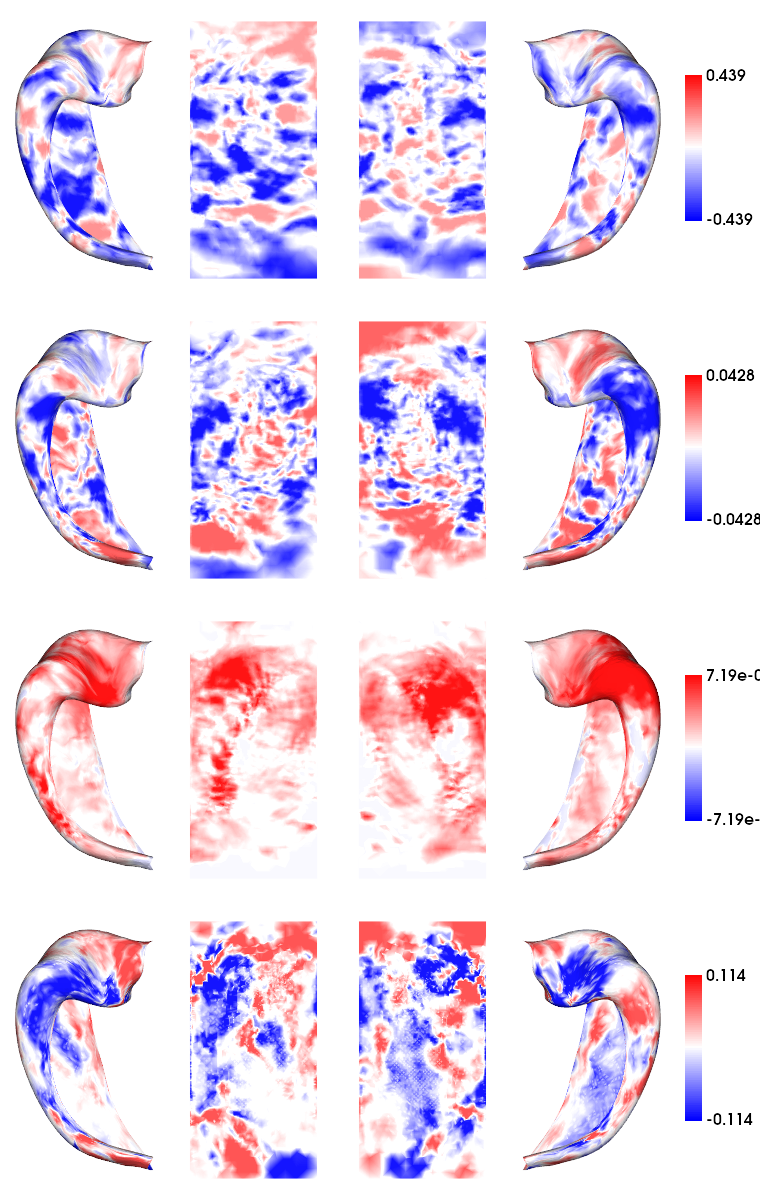

In [12]:
caseCtrl_diff = np.zeros_like(hippTau_PX)
for s in range(caseCtrl_diff.shape[2]):
    caseCtrl_diff[:,:,s,:] = hippTau_PX[:,:,s,:] - np.nanmean(hippTau_HC,axis=2)


hm.plotting.surfplot_canonical_foldunfold(np.nanmean(caseCtrl_diff,axis=2),labels=labels, hemis=hemis, tighten_cwindow=True, color_range='sym', color_bar='right', cmap = 'bwr', share='row', den=den, embed_nb=True)